# Combinatorial CoWork 2026 — Notebook 04: Invariants and visual payoff

Learning goals:
- Compute cheap invariant summaries from an `EncodingResult` without leaving the workflow layer.
- Inspect signed-measure, image, and landscape constructions as interpretable summaries of the same encoded module.
- Close with an exact 2D matching-distance computation on a shared encoding, if runtime allows.


## Outline

1. Rebuild the shifted-rectangle pair from notebook 02
2. Inspect cheap invariants first
3. Add one dims-first `H^1` support visual from `stage=:cohomology_dims`
4. Add signed-measure summaries
5. Build a multiparameter image and landscape
6. Close with exact 2D distance and export the main visuals


In [19]:
NOTEBOOK_STEM = "04_invariants_and_visual_payoff"

_TO_ROOT = let
    dir = abspath(pwd())
    root = nothing
    while true
        if isfile(joinpath(dir, "Project.toml")) && isfile(joinpath(dir, "src", "TamerOp.jl"))
            root = dir
            break
        end
        parent = dirname(dir)
        parent == dir && error("Could not locate repo root containing Project.toml and src/TamerOp.jl from pwd()=$(pwd()).")
        dir = parent
    end
    root
end

import Pkg
Pkg.activate(_TO_ROOT; io=devnull)

if !isdefined(Main, :TamerOp)
    @eval Main using TamerOp
end

TO = Main.TamerOp
using CairoMakie

CM = TO.CoreModules
OPT = TO.Options
sc = TO.SessionCache()
outdir = joinpath(_TO_ROOT, "examples", "_outputs", "combinatorial_cowork_2026", NOTEBOOK_STEM)
mkpath(outdir)


"/home/eriknovak/Documents/duke_fall_2025/tamer-op/examples/_outputs/combinatorial_cowork_2026/04_invariants_and_visual_payoff"

## 1. Rebuild the shared-encoding rectangle pair

We intentionally reuse the algebra notebook protagonists so the invariant story feels like a payoff, not a new branch. The rectangle modules come directly from `SyntheticData.orthant_bar_flange(...)`.


In [20]:
FM = TO.SyntheticData.orthant_bar_flange(
    bars=[([0, 0], [2, 2])],
    field=CM.QQField(),
)

FN = TO.SyntheticData.orthant_bar_flange(
    bars=[([1, 1], [3, 3])],
    field=CM.QQField(),
)

enc_opts = OPT.EncodingOptions(backend=:zn, max_regions=50_000, poset_kind=:signature)
encM, encN = TO.encode((FM, FN), enc_opts; cache=sc)
opts = OPT.InvariantOptions(threads=false)

(; M=TO.describe(encM), N=TO.describe(encN), shared_classifier=(TO.encoding_map(encM) === TO.encoding_map(encN)))


(M = (kind = :encoding_result, poset_type = TamerOp.ZnEncoding.SignaturePoset{1, 1}, module_type = TamerOp.Modules.PModule{Rational{BigInt}, TamerOp.CoreModules.CoeffFields.QQField, Matrix{Rational{BigInt}}, TamerOp.ZnEncoding.SignaturePoset{1, 1}}, encoding_map_type = TamerOp.EncodingCore.CompiledEncoding{TamerOp.ZnEncoding.ZnEncodingMap{2, 1, 1}, TamerOp.ZnEncoding.SignaturePoset{1, 1}, Tuple{Vector{Int64}, Vector{Int64}}, Vector{Tuple{Int64, Int64}}, TamerOp.CoreModules.EncodingCache}, compiled = true, backend = :zn, has_cohomology = true, has_presentation = true, module_dims = [0, 0, 0, 0, 0, 1, 1, 0, 0]), N = (kind = :encoding_result, poset_type = TamerOp.ZnEncoding.SignaturePoset{1, 1}, module_type = TamerOp.Modules.PModule{Rational{BigInt}, TamerOp.CoreModules.CoeffFields.QQField, Matrix{Rational{BigInt}}, TamerOp.ZnEncoding.SignaturePoset{1, 1}}, encoding_map_type = TamerOp.EncodingCore.CompiledEncoding{TamerOp.ZnEncoding.ZnEncodingMap{2, 1, 1}, TamerOp.ZnEncoding.SignaturePose

## 2. Cheap invariants first

Before asking for heavier images or landscapes, inspect the cheapest meaningful summaries. We also build one explicit visual summary directly from a visualization spec.


In [21]:
ri = TO.rank_invariant(encM; opts=opts, cache=sc)
rh = TO.restricted_hilbert(encM; opts=opts, cache=sc)
eu = TO.euler_surface(encM; opts=opts, cache=sc)
rank_spec = TO.Visualization.visual_spec(ri; kind=:rank_heatmap)

(; rank_summary=TO.describe(ri),
   hilbert_values=rh,
   euler_surface_size=size(eu),
   rank_heatmap_summary=TO.Visualization.visual_summary(rank_spec))


(rank_summary = (kind = :rank_invariant, nentries = 3, nnonzero = 3, store_zeros = false, nvertices = 9, poset_type = TamerOp.ZnEncoding.SignaturePoset{1, 1}), hilbert_values = [0, 0, 0, 0, 0, 1, 1, 0, 0], euler_surface_size = (5, 5), rank_heatmap_summary = (kind = :visualization_spec, visual_kind = :rank_heatmap, title = "Rank invariant heatmap", subtitle = "rank values on comparable poset pairs", nlayers = 1, npanels = 0, layer_types = (:HeatmapLayer,), axes = (xlabel = "target region b", ylabel = "source region a", xlimits = (0.5, 9.5), ylimits = (0.5, 9.5), zlabel = "z", zlimits = nothing, aspect = :auto, xticks = ([1, 2, 3, 4, 5, 6, 7, 8, 9], ["1", "2", "3", "4", "5", "6", "7", "8", "9"]), yticks = ([1, 2, 3, 4, 5, 6, 7, 8, 9], ["1", "2", "3", "4", "5", "6", "7", "8", "9"])), metadata = (object = :rank_invariant, nvertices = 9, nstored = 3, figure_size = (720, 620), legend_position = :none), legend_visible = false, interaction = (hover = false, labels = false, clicks = false, widg

## 3. Aside: `stage=:cohomology_dims` and an `H^1` dimension plane

This visual belongs most naturally to ingestion workflows that stop at dims-only cohomology rather than a full encoded module. The synthetic rectangle story above does not need that stage, so we introduce it here as one compact aside on a tiny deterministic point cloud. The plane view is the notebook-facing version; it reads as a parameter-plane picture rather than a region-debug view.


In [22]:
pc_demo = TO.PointCloud([
    [1.0, 0.0], [0.7, 0.7], [0.0, 1.0], [-0.7, 0.7],
    [-1.0, 0.0], [-0.7, -0.7], [0.0, -1.0], [0.7, -0.7],
])

pc_filtration = TO.RipsDensityFiltration(
    ; max_dim=1,
      knn=4,
      density_k=4,
      nn_backend=:auto,
      construction=OPT.ConstructionOptions(; sparsify=:knn, collapse=:none),
)

h1_dims = TO.encode(pc_demo, pc_filtration; degree=1, stage=:cohomology_dims, field=CM.F2(), cache=:auto)
h1_support_spec = TO.Visualization.visual_spec(h1_dims; kind=:cohomology_support_plane)

(; h1_dims_summary=TO.describe(h1_dims),
   h1_support_summary=TO.Visualization.visual_summary(h1_support_spec))


(h1_dims_summary = (kind = :cohomology_dims_result, poset_type = TamerOp.FiniteFringe.ProductOfChainsPoset{2}, dims_type = Vector{Int64}, dims_length = 8, encoding_map_type = TamerOp.EncodingCore.CompiledEncoding{TamerOp.EncodingCore.GridEncodingMap{2, Float64, TamerOp.FiniteFringe.ProductOfChainsPoset{2}}, TamerOp.FiniteFringe.ProductOfChainsPoset{2}, Tuple{Vector{Float64}, Vector{Float64}}, Vector{Tuple{Float64, Float64}}, @NamedTuple{encoding_cache::TamerOp.CoreModules.EncodingCache}}, compiled = true, degree = 1, field_type = TamerOp.CoreModules.CoeffFields.PrimeField), h1_support_summary = (kind = :visualization_spec, visual_kind = :cohomology_support_plane, title = "H^1 dimension plane", subtitle = "cohomology dimensions on the bifiltration parameter plane", nlayers = 2, npanels = 0, layer_types = (:RectLayer, :HeatmapLayer), axes = (xlabel = "x1", ylabel = "x2", xlimits = (-0.3807886552931954, 1.4213203435596427), ylimits = (1.3928932188134522, 1.4213203435596427), zlabel = "z",

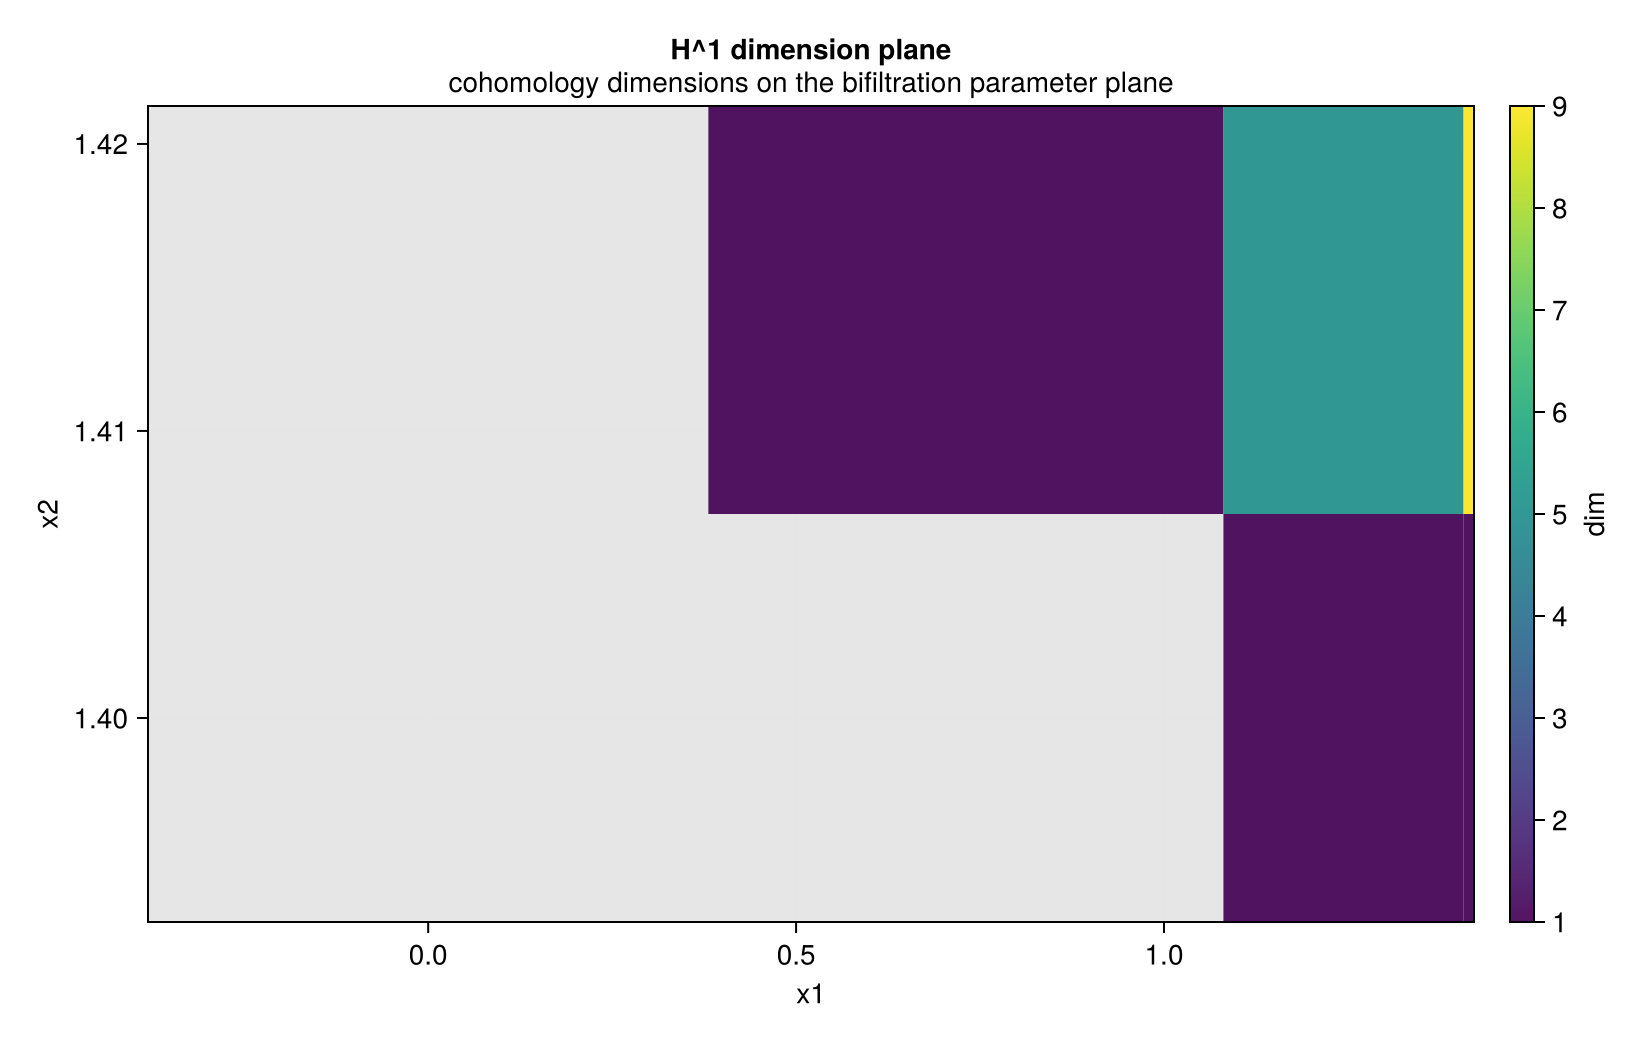

In [23]:
TO.visualize(h1_dims; kind=:cohomology_support_plane, backend=:cairomakie)


## 4. Signed-measure summaries

These objects let us summarize the same encoded module through sparse measures and rectangle barcodes before going to image-style features.


In [24]:
psm = TO.point_signed_measure(encM; opts=opts, cache=sc)
esm = TO.euler_signed_measure(encM; opts=opts, cache=sc)
sb = TO.rectangle_signed_barcode(encM; opts=opts, cache=sc)
sb_img = TO.rectangle_signed_barcode_image(encM; opts=opts, cache=sc, sigma=0.35, mode=:center)

(; point_signed_measure=TO.describe(psm),
   euler_signed_measure=TO.describe(esm),
   rectangle_signed_barcode=TO.describe(sb),
   rectangle_signed_barcode_image_size=size(sb_img))


(point_signed_measure = (kind = :point_signed_measure, ambient_dimension = 2, axis_lengths = (5, 5), nterms = 4, positive_terms = 2, negative_terms = 2, total_mass = 0, total_variation = 4, largest_terms = [(index = (2, 2), point = (0, 0), weight = 1), (index = (4, 2), point = (3, 0), weight = -1), (index = (2, 4), point = (0, 3), weight = -1), (index = (4, 4), point = (3, 3), weight = 1)]), euler_signed_measure = (kind = :point_signed_measure, ambient_dimension = 2, axis_lengths = (5, 5), nterms = 4, positive_terms = 2, negative_terms = 2, total_mass = 0, total_variation = 4, largest_terms = [(index = (2, 2), point = (0, 0), weight = 1), (index = (4, 2), point = (3, 0), weight = -1), (index = (2, 4), point = (0, 3), weight = -1), (index = (4, 4), point = (3, 3), weight = 1)]), rectangle_signed_barcode = (kind = :rect_signed_barcode, ambient_dimension = 2, axis_lengths = (5, 5), nterms = 1, positive_terms = 1, negative_terms = 0, total_mass = 1, total_variation = 1, largest_terms = @Na

## 5. Multiparameter images and landscapes

Now move to the heavier-but-still-interpretive summary objects. Again, inspect the visual summaries explicitly rather than routing through a notebook helper.


In [25]:
mpp = TO.mpp_image(encM; opts=opts, cache=sc, resolution=32, sigma=0.25, N=6, delta=:auto)
land = TO.mp_landscape(
    encM;
    opts=opts,
    cache=sc,
    directions=[(1.0, 1.0)],
    offsets=[(0.0, 0.0)],
    tgrid=collect(range(0.0, stop=1.5, length=24)),
    kmax=2,
)
mpp_spec = TO.Visualization.visual_spec(mpp; kind=:mpp_image)
land_spec = TO.Visualization.visual_spec(land; kind=:mp_landscape)

(; mpp_summary=TO.describe(mpp),
   landscape_summary=TO.describe(land),
   mpp_visual_summary=TO.Visualization.visual_summary(mpp_spec),
   landscape_visual_summary=TO.Visualization.visual_summary(land_spec))


(mpp_summary = (kind = :mpp_image, image_shape = (32, 32), sigma = 0.25, x_range = (-1.25, 4.25), y_range = (-1.1, 1.1), nsummands = 3, nlines = 17, weight_sum = 0.3516693564317312), landscape_summary = (kind = :mp_landscape, ndirections = 1, noffsets = 1, kmax = 2, grid_length = 24, values_shape = (1, 1, 2, 24), weight_shape = (1, 1), total_weight = 1.0, t_range = (0.0, 1.5), weights_normalized = true), mpp_visual_summary = (kind = :visualization_spec, visual_kind = :mpp_image, title = "Multiparameter persistence image", subtitle = "Gaussian-smoothed MPPI image", nlayers = 1, npanels = 0, layer_types = (:HeatmapLayer,), axes = (xlabel = "x1", ylabel = "x2", xlimits = (-1.25, 4.25), ylimits = (-1.1, 1.1), zlabel = "z", zlimits = nothing, aspect = :data, xticks = nothing, yticks = nothing), metadata = (image_shape = (32, 32), sigma = 0.25, nsummands = 3), legend_visible = false, interaction = (hover = false, labels = false, clicks = false, widgets = (), notebook = :summary_card)), lands

The summaries above tell us what visual artifacts exist. The next two cells render them directly in the notebook. Keep them separate: `mpp_image` and `mp_landscape` answer related but different visual questions.


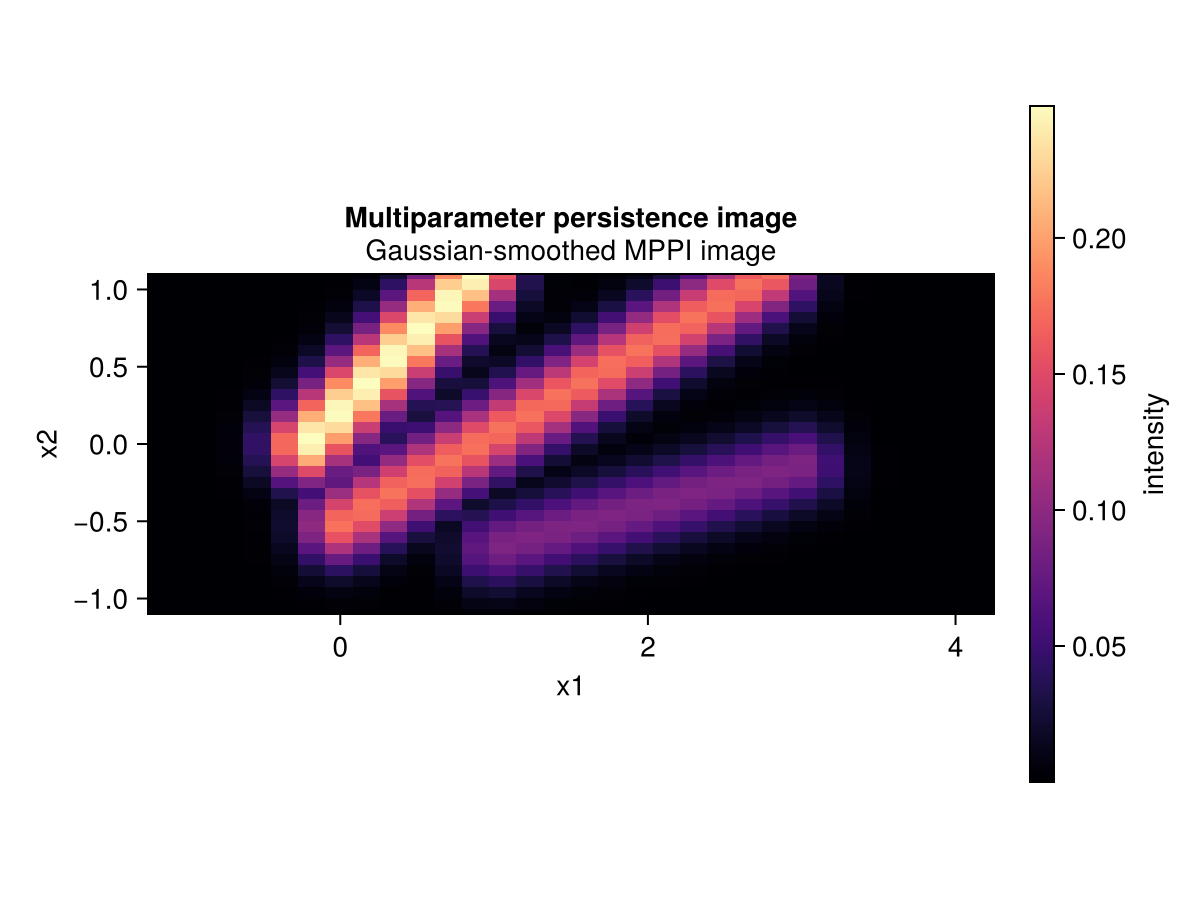

In [26]:
TO.visualize(mpp; kind=:mpp_image, backend=:cairomakie)


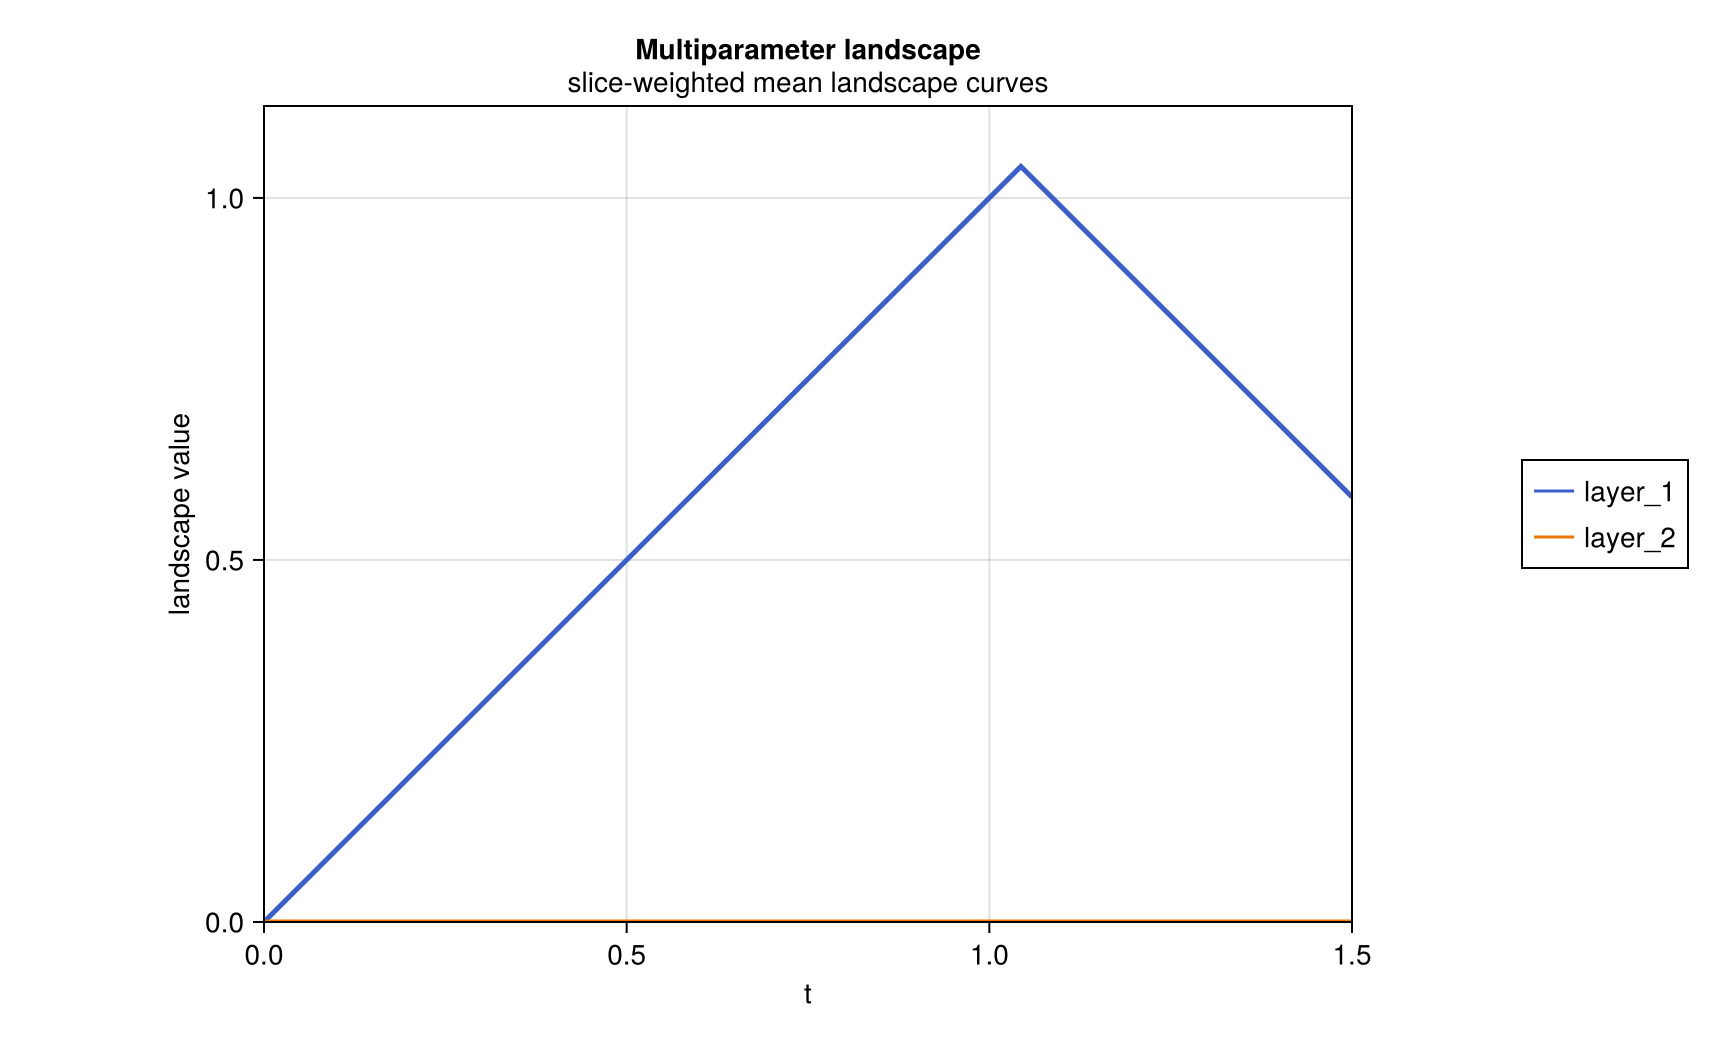

In [27]:
TO.visualize(land; kind=:mp_landscape, backend=:cairomakie)


## 6. Exact 2D distance and export the main visuals

The same shared encoding now supports an exact 2D comparison, and the same notebook can export the key visual artifacts.


In [28]:
d_exact = TO.matching_distance_exact_2d(encM, encN; opts=opts, cache=sc)
exports = TO.save_visuals(
    outdir,
    [
        (; stem="rank_heatmap", obj=ri, kind=:rank_heatmap),
        (; stem="mpp_image", obj=mpp, kind=:mpp_image),
        (; stem="mp_landscape", obj=land, kind=:mp_landscape),
    ];
    format=:png,
    backend=:cairomakie,
)

(; exact_matching_distance=d_exact,
   exported_paths=Dict(TO.export_stem(r) => TO.export_path(r) for r in exports))


(exact_matching_distance = 0.7916666666666667, exported_paths = Dict("mpp_image" => "/home/eriknovak/Documents/duke_fall_2025/tamer-op/examples/_outputs/combinatorial_cowork_2026/04_invariants_and_visual_payoff/mpp_image.png", "rank_heatmap" => "/home/eriknovak/Documents/duke_fall_2025/tamer-op/examples/_outputs/combinatorial_cowork_2026/04_invariants_and_visual_payoff/rank_heatmap.png", "mp_landscape" => "/home/eriknovak/Documents/duke_fall_2025/tamer-op/examples/_outputs/combinatorial_cowork_2026/04_invariants_and_visual_payoff/mp_landscape.png"))

## Try this next

Move the second rectangle farther away, rerun the notebook from cell 1 onward, and compare the rank summary, signed-measure summary, and exact matching distance.


In [29]:
FN_far = TO.SyntheticData.orthant_bar_flange(
    bars=[([2, 2], [4, 4])],
    field=CM.QQField(),
)

encM_far, encN_far = TO.encode((FM, FN_far), enc_opts; cache=sc)
ri_far = TO.rank_invariant(encM_far; opts=opts, cache=sc)

(; far_rank_summary=TO.describe(ri_far),
   far_exact_matching_distance=TO.matching_distance_exact_2d(encM_far, encN_far; opts=opts, cache=sc))


(far_rank_summary = (kind = :rank_invariant, nentries = 3, nnonzero = 3, store_zeros = false, nvertices = 9, poset_type = TamerOp.ZnEncoding.SignaturePoset{1, 1}), far_exact_matching_distance = 1.2329545454545452)